# Experiment 2. Image Augmentation

    Cascade stage 2: compare training without random augmentation against the current project augmentation.

Before running this notebook, update `CASCADE_INPUTS` in the configuration cell with the winner from the previous cascade stage.

In [1]:
from __future__ import annotations

import copy
import json
import os
import random
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torchvision.transforms as T
from PIL import Image
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)
from torch import nn, optim
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision.transforms import InterpolationMode
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

In [2]:
EXPERIMENT_ID = 'exp2_augmentation'
EXPERIMENT_TITLE = 'Experiment 2. Image Augmentation'
EXPERIMENT_DESCRIPTION = 'Cascade stage 2: compare training without random augmentation against the current project augmentation.'
EXPERIMENT_TYPE = 'stage'

DATASET_DIR = Path("/kaggle/input/datasets/bloodlaac/products-dataset/v3")
# DATASET_DIR = Path("/Users/bloodlaac/Projects/univer/graduation/datasets/v3")

OUTPUT_ROOT = Path("cascade_resnet_experiments")
EXPERIMENT_DIR = OUTPUT_ROOT / EXPERIMENT_ID
EXPERIMENT_DIR.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = ["Fresh", "Bad"]
CLASS_TO_IDX = {name: idx for idx, name in enumerate(CLASS_NAMES)}
POSITIVE_LABEL_NAME = "Bad"
POSITIVE_LABEL_IDX = CLASS_TO_IDX[POSITIVE_LABEL_NAME]

RANDOM_SEED = 42
TRAIN_SPLIT = 0.60
VAL_SPLIT = 0.20
TEST_SPLIT = 0.20
IMAGE_MEAN = [0.485, 0.456, 0.406]
IMAGE_STD = [0.229, 0.224, 0.225]
LOSS_FUNCTION_NAME = "CrossEntropyLoss"
OPTIMIZER_NAME = "Adam"

BASE_CONFIG = {'architecture_name': 'resnet18',
 'augmentation_name': 'current',
 'image_size': 224,
 'epochs': 20,
 'learning_rate': 0.001,
 'batch_size': 32}
CASCADE_INPUTS = {
    'best_architecture': 'resnet18',  # update after experiment 1
}
EXPERIMENT_RUNS = [{'run_label': 'B1_no_augmentation',
  'display_name': 'B1: No augmentation',
  'augmentation_name': 'none'},
 {'run_label': 'B2_current_augmentation',
  'display_name': 'B2: Current augmentation',
  'augmentation_name': 'current'}]

SELECTION_VARIABLE_NAME = 'best_augmentation'
SELECTION_SOURCE_KEY = 'augmentation_name'
SELECTION_LABEL = 'augmentation'

print(EXPERIMENT_TITLE)
print(EXPERIMENT_DESCRIPTION)
print("Dataset directory:", DATASET_DIR)
print("Output directory:", EXPERIMENT_DIR.resolve())

Experiment 2. Image Augmentation
Cascade stage 2: compare training without random augmentation against the current project augmentation.
Dataset directory: /kaggle/input/datasets/bloodlaac/products-dataset/v3
Output directory: /kaggle/working/cascade_resnet_experiments/exp2_augmentation


In [3]:
def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)


seed_everything(RANDOM_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
AMP_ENABLED = device.type == "cuda"
PIN_MEMORY = device.type == "cuda"
CHANNELS_LAST = device.type == "cuda"
NUM_WORKERS = 2 if device.type == "cuda" else 0
EVAL_BATCH_SIZE_FLOOR = 64

if torch.backends.cudnn.is_available():
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print("Using device:", device)


def to_serializable(value):
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, dict):
        return {str(key): to_serializable(item) for key, item in value.items()}
    if isinstance(value, (list, tuple)):
        return [to_serializable(item) for item in value]
    if isinstance(value, np.generic):
        return value.item()
    return value


def save_json(payload: dict, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as file:
        json.dump(to_serializable(payload), file, ensure_ascii=False, indent=2)


def seed_worker(worker_id: int) -> None:
    worker_seed = RANDOM_SEED + worker_id
    random.seed(worker_seed)
    np.random.seed(worker_seed)
    torch.manual_seed(worker_seed)


def build_fill_value(image_mean: list[float]) -> tuple[int, int, int]:
    return tuple(int(255 * value) for value in image_mean)


def build_eval_transforms(image_size: int) -> T.Compose:
    return T.Compose(
        [
            T.Resize((image_size, image_size), interpolation=InterpolationMode.BILINEAR),
            T.ToTensor(),
            T.Normalize(IMAGE_MEAN, IMAGE_STD),
        ]
    )


def build_train_transforms(image_size: int, augmentation_name: str) -> T.Compose:
    if augmentation_name == "none":
        return build_eval_transforms(image_size)

    if augmentation_name != "current":
        raise ValueError(f"Unsupported augmentation_name: {augmentation_name}")

    fill = build_fill_value(IMAGE_MEAN)
    return T.Compose(
        [
            T.Resize(int(image_size * 1.20), interpolation=InterpolationMode.BILINEAR),
            T.RandomResizedCrop(
                image_size,
                interpolation=InterpolationMode.BILINEAR,
                antialias=True,
            ),
            T.RandomHorizontalFlip(p=0.3),
            T.ColorJitter(
                brightness=0.15,
                contrast=0.15,
                saturation=0.10,
                hue=0.03,
            ),
            T.RandomAffine(
                degrees=0,
                translate=(0.08, 0.08),
                scale=(0.95, 1.05),
                shear=(-4, 4),
                interpolation=InterpolationMode.BILINEAR,
                fill=fill,
            ),
            T.ToTensor(),
            T.Normalize(IMAGE_MEAN, IMAGE_STD),
        ]
    )


class LabeledDataset(Dataset):
    def __init__(self, food_dir: Path, class_names: list[str], transform=None) -> None:
        self.food_dir = Path(food_dir)
        self.class_names = list(class_names)
        self.transform = transform
        self.image_paths: list[Path] = []
        self.labels: list[int] = []

        for class_name in self.class_names:
            class_dir = self.food_dir / class_name
            if not class_dir.exists():
                raise FileNotFoundError(f"Class directory not found: {class_dir}")

            for image_path in sorted(class_dir.iterdir()):
                if image_path.is_file():
                    self.image_paths.append(image_path)
                    self.labels.append(CLASS_TO_IDX[class_name])

    def __len__(self) -> int:
        return len(self.image_paths)

    def __getitem__(self, index: int):
        image = Image.open(self.image_paths[index]).convert("RGB")
        label = self.labels[index]
        if self.transform is not None:
            image = self.transform(image)
        return image, label


def split_indices(
    dataset_len: int,
    train_split: float,
    val_split: float,
    seed: int,
) -> tuple[list[int], list[int], list[int]]:
    if dataset_len <= 0:
        raise ValueError("Dataset is empty.")

    train_size = int(dataset_len * train_split)
    val_size = int(dataset_len * val_split)
    test_size = dataset_len - train_size - val_size
    if min(train_size, val_size, test_size) <= 0:
        raise ValueError(
            f"Invalid split sizes: train={train_size}, val={val_size}, test={test_size}"
        )

    generator = torch.Generator().manual_seed(seed)
    indices = torch.randperm(dataset_len, generator=generator).tolist()

    train_indices = indices[:train_size]
    val_indices = indices[train_size : train_size + val_size]
    test_indices = indices[train_size + val_size :]
    return train_indices, val_indices, test_indices


def build_dataloaders(
    dataset_dir: Path,
    image_size: int,
    augmentation_name: str,
    batch_size: int,
    train_indices: list[int],
    val_indices: list[int],
    test_indices: list[int],
) -> tuple[DataLoader, DataLoader, DataLoader]:
    train_dataset = Subset(
        LabeledDataset(
            dataset_dir,
            CLASS_NAMES,
            transform=build_train_transforms(image_size, augmentation_name),
        ),
        train_indices,
    )
    val_dataset = Subset(
        LabeledDataset(
            dataset_dir,
            CLASS_NAMES,
            transform=build_eval_transforms(image_size),
        ),
        val_indices,
    )
    test_dataset = Subset(
        LabeledDataset(
            dataset_dir,
            CLASS_NAMES,
            transform=build_eval_transforms(image_size),
        ),
        test_indices,
    )

    train_generator = torch.Generator().manual_seed(RANDOM_SEED)
    eval_batch_size = max(EVAL_BATCH_SIZE_FLOOR, batch_size)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        generator=train_generator,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        worker_init_fn=seed_worker if NUM_WORKERS > 0 else None,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=eval_batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        worker_init_fn=seed_worker if NUM_WORKERS > 0 else None,
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=eval_batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        worker_init_fn=seed_worker if NUM_WORKERS > 0 else None,
    )

    return train_loader, val_loader, test_loader


class Block(nn.Module):
    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        stride: int = 1,
        downsampling: nn.Module | None = None,
    ) -> None:
        super().__init__()
        self.conv1 = nn.Conv2d(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
        )
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv2d(
            in_channels=out_channels,
            out_channels=out_channels,
            kernel_size=3,
            stride=1,
            padding=1,
        )
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.downsampling = downsampling

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        shortcut = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        if self.downsampling is not None:
            shortcut = self.downsampling(x)
        out += shortcut
        out = self.relu(out)
        return out


class ResNet(nn.Module):
    def __init__(self, blocks_num_list: list[int], num_classes: int = 2) -> None:
        super().__init__()
        self.in_channels = 64
        self.conv1 = nn.Conv2d(
            in_channels=3,
            out_channels=64,
            kernel_size=7,
            stride=2,
            padding=3,
        )
        self.batch_norm = nn.BatchNorm2d(64)
        self.relu = nn.ReLU()
        self.pooling = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.layer1 = self.create_layer(64, blocks_num_list[0])
        self.layer2 = self.create_layer(128, blocks_num_list[1], stride=2)
        self.layer3 = self.create_layer(256, blocks_num_list[2], stride=2)
        self.layer4 = self.create_layer(512, blocks_num_list[3], stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    def create_layer(
        self,
        out_channels: int,
        num_blocks: int,
        stride: int = 1,
    ) -> nn.Sequential:
        downsampling = None
        if stride != 1:
            downsampling = nn.Sequential(
                nn.Conv2d(
                    in_channels=self.in_channels,
                    out_channels=out_channels,
                    kernel_size=1,
                    stride=stride,
                ),
                nn.BatchNorm2d(out_channels),
            )

        blocks = [
            Block(
                in_channels=self.in_channels,
                out_channels=out_channels,
                stride=stride,
                downsampling=downsampling,
            )
        ]
        self.in_channels = out_channels
        for _ in range(num_blocks - 1):
            blocks.append(Block(out_channels, out_channels))
        return nn.Sequential(*blocks)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = self.conv1(x)
        out = self.batch_norm(out)
        out = self.relu(out)
        out = self.pooling(out)

        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)

        out = self.avgpool(out)
        out = torch.flatten(out, 1)
        out = self.fc(out)
        return out


def build_model(blocks_num_list: list[int]) -> ResNet:
    model = ResNet(
        blocks_num_list=blocks_num_list,
        num_classes=len(CLASS_NAMES),
    ).to(device)
    if CHANNELS_LAST:
        model = model.to(memory_format=torch.channels_last)
    return model


def build_optimizer(model: nn.Module, learning_rate: float):
    if OPTIMIZER_NAME.lower() == "adam":
        return optim.Adam(model.parameters(), lr=learning_rate)
    raise ValueError(f"Unsupported OPTIMIZER_NAME: {OPTIMIZER_NAME}")


def build_criterion():
    if LOSS_FUNCTION_NAME != "CrossEntropyLoss":
        raise ValueError(f"Unsupported LOSS_FUNCTION_NAME: {LOSS_FUNCTION_NAME}")
    return nn.CrossEntropyLoss()


def move_images_to_device(images: torch.Tensor) -> torch.Tensor:
    images = images.to(device, non_blocking=PIN_MEMORY)
    if CHANNELS_LAST:
        images = images.contiguous(memory_format=torch.channels_last)
    return images


def validate(model: nn.Module, loader: DataLoader, criterion: nn.Module) -> tuple[float, float]:
    model.eval()
    total = 0
    correct = 0
    total_loss = 0.0

    with torch.no_grad():
        for images, labels in loader:
            images = move_images_to_device(images)
            labels = labels.to(device, non_blocking=PIN_MEMORY)

            with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=AMP_ENABLED):
                logits = model(images)
                loss = criterion(logits, labels)

            preds = torch.argmax(logits, dim=1)
            batch_size = len(labels)
            total += batch_size
            total_loss += loss.item() * batch_size
            correct += (preds == labels).sum().item()

    accuracy = correct / total
    avg_loss = total_loss / total
    return accuracy, avg_loss


def is_better_validation(
    candidate_accuracy: float,
    candidate_loss: float,
    best_accuracy: float,
    best_loss: float,
) -> bool:
    if candidate_accuracy > best_accuracy and not np.isclose(candidate_accuracy, best_accuracy):
        return True
    if np.isclose(candidate_accuracy, best_accuracy):
        return candidate_loss < best_loss
    return False


def train_model(
    model: nn.Module,
    criterion: nn.Module,
    optimizer,
    train_loader: DataLoader,
    val_loader: DataLoader,
    epochs: int,
) -> dict:
    history_rows = []
    best_model_state = copy.deepcopy(model.state_dict())
    best_val_accuracy = -float("inf")
    best_val_loss = float("inf")
    best_epoch = 0
    scaler = torch.amp.GradScaler("cuda", enabled=AMP_ENABLED)

    if device.type == "cuda":
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats(device)

    training_start = time.perf_counter()

    for epoch in tqdm(range(1, epochs + 1), desc="Training", leave=False):
        model.train()
        total = 0
        correct = 0
        total_loss = 0.0
        epoch_start = time.perf_counter()

        for images, labels in train_loader:
            images = move_images_to_device(images)
            labels = labels.to(device, non_blocking=PIN_MEMORY)

            optimizer.zero_grad(set_to_none=True)

            with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=AMP_ENABLED):
                logits = model(images)
                loss = criterion(logits, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            preds = torch.argmax(logits, dim=1)
            batch_size = len(labels)
            total += batch_size
            total_loss += loss.item() * batch_size
            correct += (preds == labels).sum().item()

        train_accuracy = correct / total
        train_loss = total_loss / total
        val_accuracy, val_loss = validate(model, val_loader, criterion)
        epoch_seconds = time.perf_counter() - epoch_start

        history_rows.append(
            {
                "epoch": epoch,
                "train_loss": train_loss,
                "val_loss": val_loss,
                "train_accuracy": train_accuracy,
                "val_accuracy": val_accuracy,
                "epoch_seconds": epoch_seconds,
            }
        )

        if is_better_validation(val_accuracy, val_loss, best_val_accuracy, best_val_loss):
            best_val_accuracy = val_accuracy
            best_val_loss = val_loss
            best_epoch = epoch
            best_model_state = copy.deepcopy(model.state_dict())

    total_training_seconds = time.perf_counter() - training_start
    max_memory_allocated_mb = None
    if device.type == "cuda":
        max_memory_allocated_mb = torch.cuda.max_memory_allocated(device) / (1024 ** 2)

    model.load_state_dict(best_model_state)

    return {
        "history_rows": history_rows,
        "best_model_state": best_model_state,
        "best_val_accuracy": best_val_accuracy,
        "best_val_loss": best_val_loss,
        "best_epoch": best_epoch,
        "total_training_seconds": total_training_seconds,
        "max_memory_allocated_mb": max_memory_allocated_mb,
    }


def evaluate_model(model: nn.Module, loader: DataLoader, criterion: nn.Module) -> dict:
    model.eval()
    total = 0
    correct = 0
    total_loss = 0.0
    y_true: list[int] = []
    y_pred: list[int] = []

    with torch.no_grad():
        for images, labels in loader:
            images = move_images_to_device(images)
            labels = labels.to(device, non_blocking=PIN_MEMORY)

            with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=AMP_ENABLED):
                logits = model(images)
                loss = criterion(logits, labels)

            preds = torch.argmax(logits, dim=1)
            batch_size = len(labels)
            total += batch_size
            total_loss += loss.item() * batch_size
            correct += (preds == labels).sum().item()
            y_true.extend(labels.cpu().tolist())
            y_pred.extend(preds.cpu().tolist())

    precision, recall, f1_score, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="binary",
        pos_label=POSITIVE_LABEL_IDX,
        zero_division=0,
    )
    _, _, macro_f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="macro",
        zero_division=0,
    )
    _, _, weighted_f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0,
    )
    report_text = classification_report(
        y_true,
        y_pred,
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0,
    )
    report_dict = classification_report(
        y_true,
        y_pred,
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0,
        output_dict=True,
    )

    return {
        "test_accuracy": correct / total,
        "test_loss": total_loss / total,
        "precision": precision,
        "recall": recall,
        "f1_score": f1_score,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "classification_report_text": report_text,
        "classification_report_dict": report_dict,
        "confusion_matrix": confusion_matrix(y_true, y_pred),
    }


def plot_training_curves(history_df: pd.DataFrame, title: str, output_path: Path) -> None:
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

    ax1.plot(history_df["epoch"], history_df["train_loss"], label="Train loss")
    ax1.plot(history_df["epoch"], history_df["val_loss"], label="Validation loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.set_title(f"Loss curves | {title}")
    ax1.grid(True)
    ax1.legend()

    ax2.plot(history_df["epoch"], history_df["train_accuracy"], label="Train accuracy")
    ax2.plot(history_df["epoch"], history_df["val_accuracy"], label="Validation accuracy")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.set_title(f"Accuracy curves | {title}")
    ax2.grid(True)
    ax2.legend()

    fig.tight_layout()
    fig.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)


def plot_summary_bar(summary_df: pd.DataFrame, title: str, output_path: Path) -> None:
    plot_df = summary_df[summary_df["status"] == "ok"].copy()
    if plot_df.empty:
        print("No successful runs to plot.")
        return

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(plot_df["display_name"], plot_df["best_val_accuracy"], color="#4C956C")
    ax.set_ylim(0, 1)
    ax.set_xlabel("Variant")
    ax.set_ylabel("Validation accuracy")
    ax.set_title(title)
    ax.grid(True, axis="y")
    plt.xticks(rotation=15, ha="right")
    fig.tight_layout()
    fig.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)


def plot_confusion_matrix(cm: np.ndarray, title: str, output_path: Path) -> None:
    fig, ax = plt.subplots(figsize=(6, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
    disp.plot(ax=ax, cmap=plt.cm.Blues, colorbar=False)
    ax.set_title(title)
    fig.tight_layout()
    fig.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)


def resolve_config(run_spec: dict) -> dict:
    config = dict(BASE_CONFIG)
    config["architecture_name"] = CASCADE_INPUTS.get("best_architecture", config["architecture_name"])
    config["augmentation_name"] = CASCADE_INPUTS.get("best_augmentation", config["augmentation_name"])
    config["image_size"] = CASCADE_INPUTS.get("best_image_size", config["image_size"])
    config["epochs"] = CASCADE_INPUTS.get("best_epochs", config["epochs"])
    config["learning_rate"] = CASCADE_INPUTS.get("best_learning_rate", config["learning_rate"])
    config["batch_size"] = CASCADE_INPUTS.get("best_batch_size", config["batch_size"])
    config.update(run_spec)

    if "blocks_num_list" not in config:
        block_map = {
            "resnet18": [2, 2, 2, 2],
            "resnet34": [3, 4, 6, 3],
        }
        config["blocks_num_list"] = block_map[config["architecture_name"]]

    return config


def flatten_result(result: dict) -> dict:
    keys = [
        "run_label",
        "display_name",
        "status",
        "architecture_name",
        "augmentation_name",
        "image_size",
        "epochs",
        "learning_rate",
        "batch_size",
        "best_epoch",
        "best_val_accuracy",
        "best_val_loss",
        "test_accuracy",
        "test_loss",
        "precision",
        "recall",
        "f1_score",
        "macro_f1",
        "weighted_f1",
        "total_training_seconds",
        "max_memory_allocated_mb",
        "run_dir",
        "error_message",
    ]
    row = {}
    for key in keys:
        row[key] = result.get(key)
    return row


def select_best_result(results: list[dict]) -> dict:
    successful = [result for result in results if result["status"] == "ok"]
    if not successful:
        raise RuntimeError("No successful runs were completed.")

    best_result = successful[0]
    for result in successful[1:]:
        if is_better_validation(
            result["best_val_accuracy"],
            result["best_val_loss"],
            best_result["best_val_accuracy"],
            best_result["best_val_loss"],
        ):
            best_result = result
    return best_result


def is_oom_error(exc: Exception) -> bool:
    message = str(exc).lower()
    return "out of memory" in message or "cuda error: out of memory" in message


def run_single_experiment(
    config: dict,
    train_indices: list[int],
    val_indices: list[int],
    test_indices: list[int],
) -> dict:
    seed_everything(RANDOM_SEED)
    run_dir = EXPERIMENT_DIR / config["run_label"]
    run_dir.mkdir(parents=True, exist_ok=True)
    history_path = run_dir / "history.csv"
    curves_path = run_dir / "training_curves.png"

    print(
        f"\nRunning {config['display_name']} | "
        f"arch={config['architecture_name']}, aug={config['augmentation_name']}, "
        f"image_size={config['image_size']}, epochs={config['epochs']}, "
        f"lr={config['learning_rate']}, batch_size={config['batch_size']}"
    )

    try:
        if device.type == "cuda":
            torch.cuda.empty_cache()

        train_loader, val_loader, test_loader = build_dataloaders(
            dataset_dir=DATASET_DIR,
            image_size=config["image_size"],
            augmentation_name=config["augmentation_name"],
            batch_size=config["batch_size"],
            train_indices=train_indices,
            val_indices=val_indices,
            test_indices=test_indices,
        )

        model = build_model(config["blocks_num_list"])
        criterion = build_criterion()
        optimizer = build_optimizer(model, config["learning_rate"])

        training_result = train_model(
            model=model,
            criterion=criterion,
            optimizer=optimizer,
            train_loader=train_loader,
            val_loader=val_loader,
            epochs=config["epochs"],
        )
        evaluation_result = evaluate_model(model, test_loader, criterion)

        history_df = pd.DataFrame(training_result["history_rows"])
        history_df.to_csv(history_path, index=False)
        plot_training_curves(history_df, config["display_name"], curves_path)

        result = {
            **config,
            "status": "ok",
            "history_path": history_path,
            "training_curves_path": curves_path,
            "run_dir": run_dir,
            "error_message": None,
        }
        result.update(training_result)
        result.update(evaluation_result)
        return result

    except Exception as exc:
        if device.type == "cuda":
            torch.cuda.empty_cache()

        if is_oom_error(exc):
            print(f"Skipped {config['display_name']} because of OOM: {exc}")
            return {
                **config,
                "status": "oom",
                "best_epoch": None,
                "best_val_accuracy": np.nan,
                "best_val_loss": np.nan,
                "test_accuracy": np.nan,
                "test_loss": np.nan,
                "precision": np.nan,
                "recall": np.nan,
                "f1_score": np.nan,
                "macro_f1": np.nan,
                "weighted_f1": np.nan,
                "total_training_seconds": np.nan,
                "max_memory_allocated_mb": np.nan,
                "run_dir": run_dir,
                "error_message": str(exc),
            }
        raise

Using device: cuda


Split sizes: {'train': 18720, 'val': 6240, 'test': 6241}

Running B1: No augmentation | arch=resnet18, aug=none, image_size=224, epochs=20, lr=0.001, batch_size=32


Training:   0%|          | 0/20 [00:00<?, ?it/s]

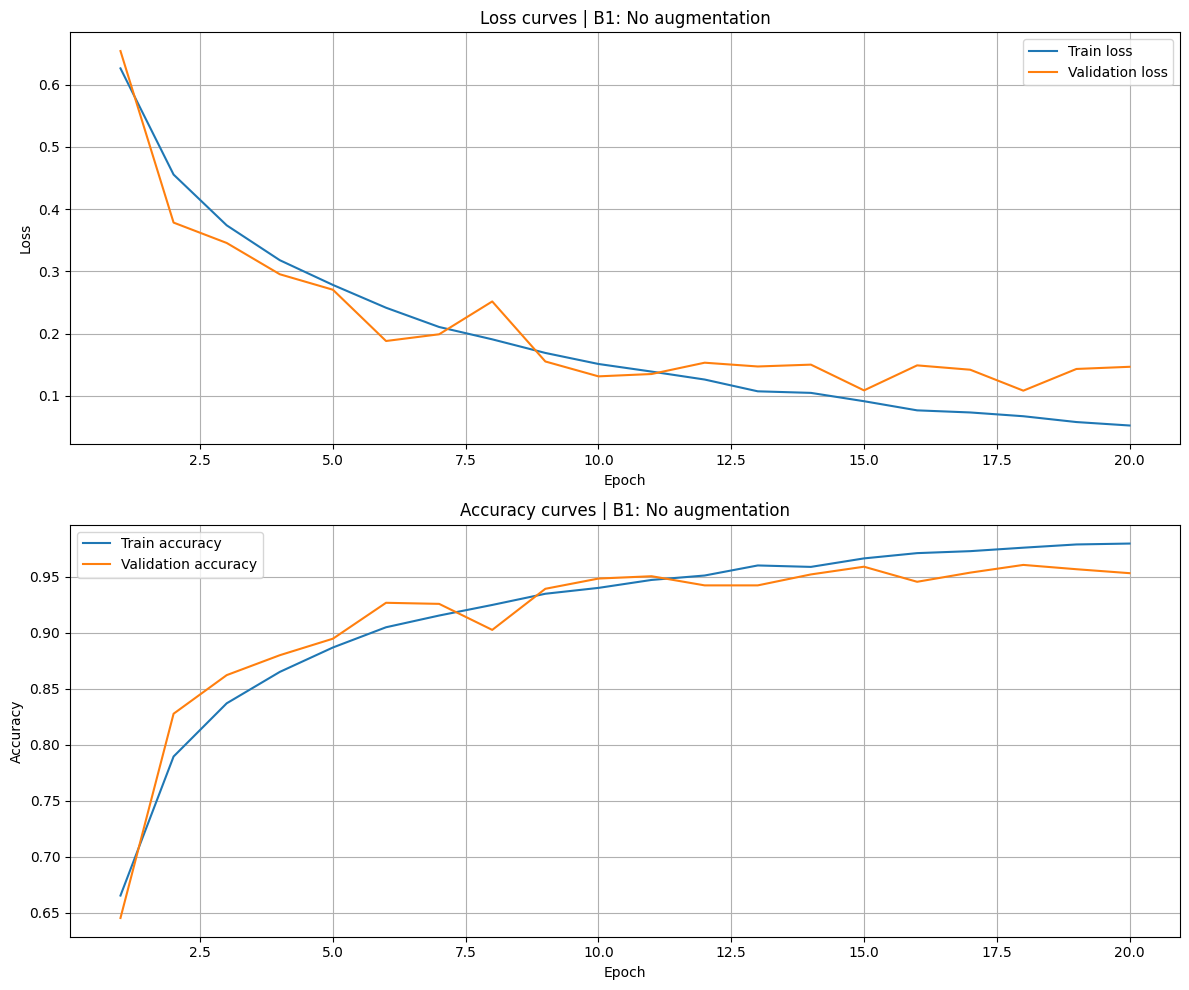


Running B2: Current augmentation | arch=resnet18, aug=current, image_size=224, epochs=20, lr=0.001, batch_size=32


Training:   0%|          | 0/20 [00:00<?, ?it/s]

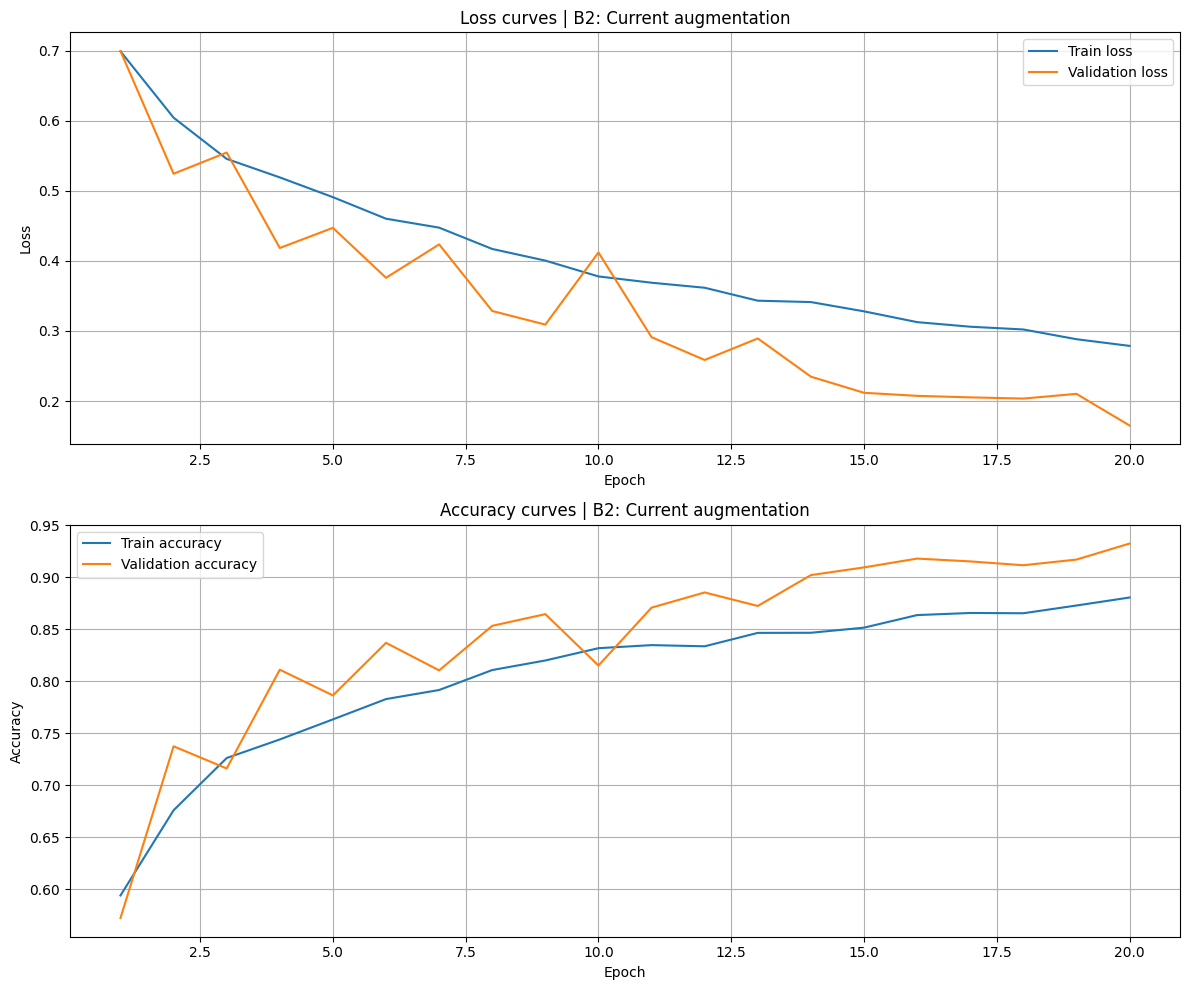

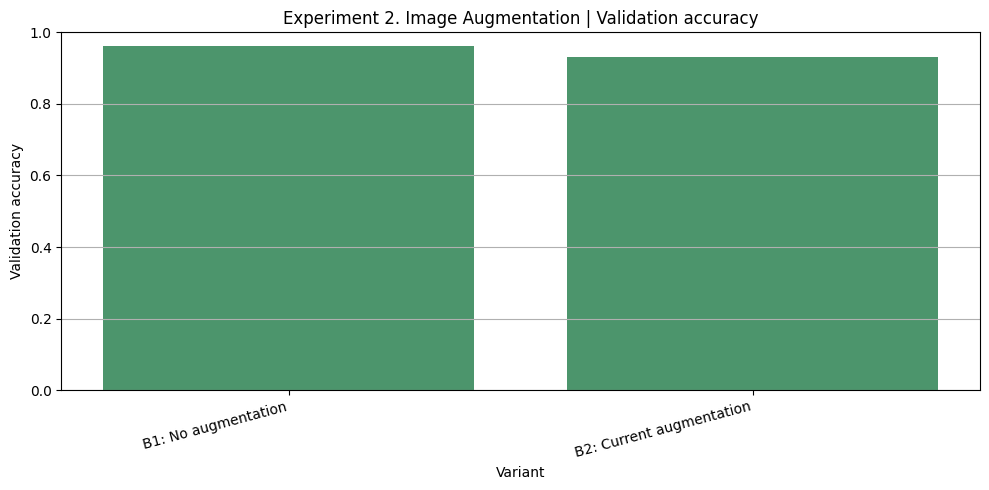

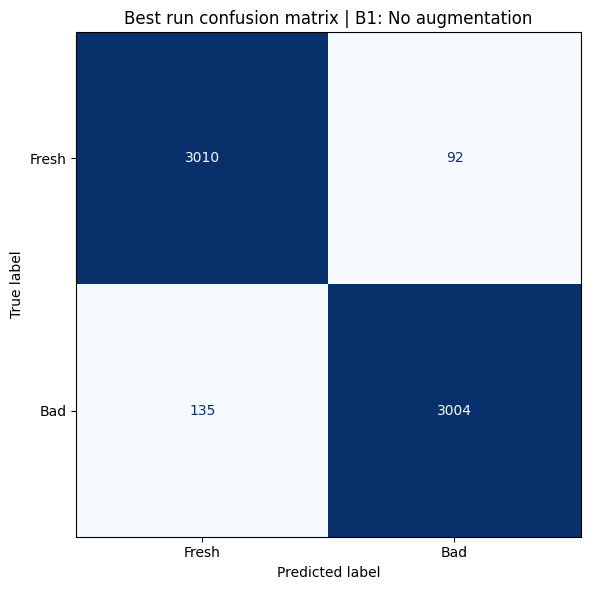

Summary:
              run_label             display_name status architecture_name augmentation_name  image_size  epochs  learning_rate  batch_size  best_epoch  best_val_accuracy  best_val_loss  test_accuracy  test_loss  precision   recall  f1_score  macro_f1  weighted_f1  total_training_seconds  max_memory_allocated_mb                                                              run_dir error_message
     B1_no_augmentation      B1: No augmentation     ok          resnet18              none         224      20          0.001          32          18           0.960577       0.108549       0.963628   0.101056   0.970284 0.956993  0.963593  0.963628     0.963627             3501.367695               620.664062      cascade_resnet_experiments/exp2_augmentation/B1_no_augmentation          None
B2_current_augmentation B2: Current augmentation     ok          resnet18           current         224      20          0.001          32          20           0.932212       0.165070       0.931742

In [4]:
dataset_probe = LabeledDataset(DATASET_DIR, CLASS_NAMES, transform=None)
train_indices, val_indices, test_indices = split_indices(
    len(dataset_probe),
    train_split=TRAIN_SPLIT,
    val_split=VAL_SPLIT,
    seed=RANDOM_SEED,
)

print(
    "Split sizes:",
    {
        "train": len(train_indices),
        "val": len(val_indices),
        "test": len(test_indices),
    },
)

results = []
for run_spec in EXPERIMENT_RUNS:
    config = resolve_config(run_spec)
    result = run_single_experiment(
        config,
        train_indices=train_indices,
        val_indices=val_indices,
        test_indices=test_indices,
    )
    results.append(result)

summary_df = pd.DataFrame(flatten_result(result) for result in results)
summary_df = summary_df.sort_values(
    by=["status", "best_val_accuracy", "best_val_loss"],
    ascending=[True, False, True],
    na_position="last",
).reset_index(drop=True)
summary_df.to_csv(EXPERIMENT_DIR / "summary.csv", index=False)

plot_summary_bar(
    summary_df,
    f"{EXPERIMENT_TITLE} | Validation accuracy",
    EXPERIMENT_DIR / "val_accuracy_comparison.png",
)

best_run = select_best_result(results)
plot_confusion_matrix(
    best_run["confusion_matrix"],
    f"Best run confusion matrix | {best_run['display_name']}",
    EXPERIMENT_DIR / "best_confusion_matrix.png",
)

with (EXPERIMENT_DIR / "best_classification_report.txt").open("w", encoding="utf-8") as file:
    file.write(best_run["classification_report_text"])

selected_value = best_run[SELECTION_SOURCE_KEY]
selection_payload = {
    "stage_id": EXPERIMENT_ID,
    "selection_variable_name": SELECTION_VARIABLE_NAME,
    "selected_value": selected_value,
    "best_run_label": best_run["run_label"],
    "best_display_name": best_run["display_name"],
    "best_epoch": best_run["best_epoch"],
    "best_val_accuracy": best_run["best_val_accuracy"],
    "best_val_loss": best_run["best_val_loss"],
    "test_accuracy": best_run["test_accuracy"],
    "test_loss": best_run["test_loss"],
}
save_json(selection_payload, EXPERIMENT_DIR / "best_selection.json")
save_json(flatten_result(best_run), EXPERIMENT_DIR / "best_run_overview.json")

print("Summary:")
print(summary_df.to_string(index=False))
print(f"\nSelected best {SELECTION_LABEL}: {selected_value!r}")
print(f"Use this in the next notebook as {SELECTION_VARIABLE_NAME} = {selected_value!r}")